Обучить две сверточные нейронные сети на бинарную классификацию кошек и собак.

Первая это простая сверточная архитектура. 

Вторая это любой предобученный на Imagenet backbone из TIMMs пригодный для данной задачи. 

Провести тест. Сравнить результаты. Сделать выводы. 

Датасет: публичный датасет Oxford-IIIT Pet

In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms as transforms
from torchmetrics.classification import (
    MulticlassAccuracy, MulticlassF1Score, MulticlassPrecision, MulticlassRecall,
    BinaryAccuracy, BinaryF1Score, BinaryPrecision, BinaryRecall,
)
#
import timm
#
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CPU")
#
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = '../data/'
IMG_SIZE    = 224
SPLIT_SEED  = 77
BATCH_SIZE  = 16
NUM_WORKERS = 2
LEARNING_RATE = 0.0001
CLASS_NAMES_CATS_DOGS = ["Cat", "Dog"]

GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Загрузка данных

In [2]:
train_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                      transforms.RandomHorizontalFlip(p=0.5),
                                      transforms.RandomRotation(degrees=15),
                                      transforms.ColorJitter(brightness=0.3, 
                                                             contrast=0.3, 
                                                             saturation=0.2),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                           std=[0.229, 0.224, 0.225])])
#
#
test_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                           std=[0.229, 0.224, 0.225])])

In [3]:
pets_trainval = OxfordIIITPet(root=DATA_DIR, split="trainval",
                              target_types='binary-category', 
                              #download=True, 
                              transform=train_transform)
pets_test = OxfordIIITPet(root=DATA_DIR, split="test",
                              target_types='binary-category', 
                              #download=True, 
                              transform=test_transform)

___

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


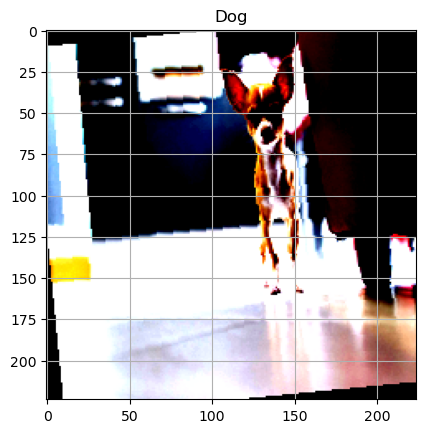

In [4]:
im, lab = pets_trainval.__getitem__(500)
plt.imshow(im.permute(1, 2, 0))
plt.title(CLASS_NAMES_CATS_DOGS[lab])
plt.grid()

In [5]:
train_loader = DataLoader(pets_trainval, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(pets_test, batch_size=BATCH_SIZE, shuffle=False)

___

## Simple ResNET

In [6]:
class SimpleResNET9(nn.Module):
    """
    Простая свёрточная нейронная сеть ResNET 9
    взята отсюда: https://www.kaggle.com/code/kmldas/cifar10-resnet-90-accuracy-less-than-5-min

    Args:
        num_classes (int): количество выходных классов
    """

    # Имя модели — сохраняется в чекпоинт для последующей загрузки
    model_name = "SimpleResNET9"

    def __init__(self, num_classes: int):
        super().__init__()

        self.block1 = nn.Sequential(
            # --- Блок 1 ---
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2))
        #
        self.res1 = nn.Sequential(
            # --- Рукурентный слой 1 ---
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True))
        #
        self.block2 = nn.Sequential(
            # --- Блок 2 ---
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2))
        #
        self.res2 = nn.Sequential(
            # --- Рукурентный слой 2 ---
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True))
        #
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),                    
            nn.Linear(512 * 4 * 4, 512),      
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),                
            nn.Linear(512, num_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        """
        x = self.block1(x)
        x = self.res1(x) + x
        x = self.block2(x)
        x = self.res2(x) + x
        x = self.classifier(x)
        return x

In [7]:
def train(model, train_loader, val_loader, 
          criterion, metric, optimizer, device, 
          scheduler, checkpoint, epochs=10):
    model.to(device)
    train_losses = []
    val_losses = []
    metric_values = []
    #
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            #
            outputs = model(images).squeeze(1)
            #
            loss = criterion(outputs, labels.float())
            #
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        #
        scheduler.step()
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        val_loss = 0
        metric_value = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images).squeeze(1)
                #
                preds = (torch.sigmoid(outputs) > 0.5).long()
                metric_value += metric(preds, labels)
                #
                loss = criterion(outputs, labels.float())
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        avg_metric = metric_value / len(val_loader)
        metric_values.append(avg_metric)
        #
        if avg_metric > checkpoint['metric']:
          checkpoint['model_state_dict'] = model.state_dict()
          checkpoint['optimizer_state_dict'] = optimizer.state_dict()
          checkpoint['loss'] = avg_val_loss
          checkpoint['metric'] = avg_metric
          checkpoint['epoch'] = epoch+1
        #
        val_losses.append(avg_val_loss)
        #
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val metric: {avg_metric:.4f}")

    return train_losses, val_losses, checkpoint

In [8]:
def draw_model_dynamic(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('CTC Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()
##

In [9]:
class BoxMachine:
    def __init__(self, model, learn_rate, device):
        self.learn_rate = learn_rate
        self.device = device
        self.model = model
        self.optimizer = optim.Adam(self.model.parameters(), lr=learn_rate)
        # 
        self.scheduler = lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.1)
        #
        self.metric = BinaryF1Score().to(device)
        self.criterion = nn.BCEWithLogitsLoss()
        #
        self.checkpoint = {
            'epoch': None,
            'model_state_dict': None,
            'optimizer_state_dict': None,
            'loss': 100,
            'metric':0
        }
    #
    def train(self, train_loader, val_loader, epochs=10):
        self.model.to(self.device)
        self.train_losses = []
        self.val_losses = []
        self.metric_values = []
        self.epochs = epochs
        #
        for epoch in range(self.epochs):
            self.model.train()
            train_loss = 0
            for images, labels in train_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                #
                outputs = self.model(images).squeeze(1)
                #
                loss = self.criterion(outputs, labels.float())
                #
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                train_loss += loss.item()
            #
            self.scheduler.step()
            avg_train_loss = train_loss / len(train_loader)
            self.train_losses.append(avg_train_loss)
            
            self.model.eval()
            val_loss = 0
            metric_value = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images = images.to(self.device)
                    labels = labels.to(self.device)
                    outputs = self.model(images).squeeze(1)
                    #
                    preds = (torch.sigmoid(outputs) > 0.5).long()
                    metric_value += self.metric(preds, labels)
                    #
                    loss = self.criterion(outputs, labels.float())
                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_loader)
            avg_metric = metric_value / len(val_loader)
            self.metric_values.append(avg_metric)
            #
            if avg_metric > self.checkpoint['metric']:
                self.checkpoint['model_state_dict'] = self.model.state_dict()
                self.checkpoint['optimizer_state_dict'] = self.optimizer.state_dict()
                self.checkpoint['loss'] = avg_val_loss
                self.checkpoint['metric'] = avg_metric
                self.checkpoint['epoch'] = epoch+1
            #
            self.val_losses.append(avg_val_loss)
            #
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val metric: {avg_metric:.4f}")

    #
    def save_checkpoint(self, path):
        torch.save(self.checkpoint, path)
        print(f'Metric: {self.checkpoint["metric"]:.4f}; Epoch: {self.checkpoint["epoch"]}')
    #
    def draw_model_dynamic(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.title('CTC Loss Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid()
        plt.show()
##

In [10]:
def evaluate(model, loader):
    accuracy = 0
    precision = 0
    recall = 0
    f1 = 0
    #
    accuracy_score = BinaryAccuracy().to(DEVICE)
    precision_score = BinaryPrecision().to(DEVICE)
    recall_score = BinaryRecall().to(DEVICE)
    f1_score = BinaryF1Score().to(DEVICE)
    #
    scale = len(loader)
    #
    model.eval()
    #
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images).squeeze(1)
            #
            preds = (torch.sigmoid(outputs) > 0.5).long()
            accuracy += accuracy_score(preds, labels)
            precision += precision_score(preds, labels)
            recall += recall_score(preds, labels)
            f1 += f1_score(preds, labels)
    #
        accuracy = accuracy / scale
        precision = precision / scale
        recall = recall / scale
        f1 = f1 / scale
    #
    print('='*50)
    print(f'Accurasy: {accuracy:.3f}')
    print(f'Precision: {precision:.3f}')
    print(f'Recall: {recall:.3f}')
    print(f'F1: {f1:.3f}')
    print('='*50)

Epoch 1/5 - Train Loss: 0.6314 - Val Loss: 0.5405 - Val metric: 0.6783
Epoch 2/5 - Train Loss: 0.5681 - Val Loss: 0.4903 - Val metric: 0.6404
Epoch 3/5 - Train Loss: 0.5351 - Val Loss: 0.4978 - Val metric: 0.6380
Epoch 4/5 - Train Loss: 0.5041 - Val Loss: 0.4980 - Val metric: 0.6796
Epoch 5/5 - Train Loss: 0.4760 - Val Loss: 0.4700 - Val metric: 0.6730


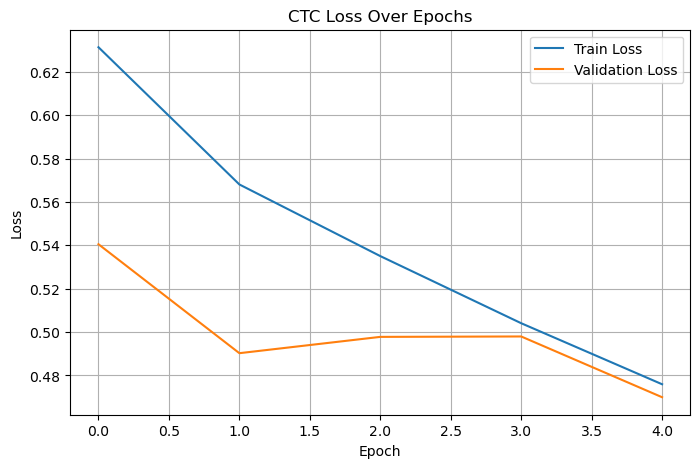

In [11]:
model = SimpleResNET9(num_classes=1)
bm = BoxMachine(model, LEARNING_RATE, DEVICE)
bm.train(train_loader, test_loader, epochs=5)
bm.draw_model_dynamic()

In [12]:
bm.save_checkpoint('../checkpoints/checkpoint_lab1_model1.pt')
bm_checkpoint = torch.load('../checkpoints/checkpoint_lab1_model1.pt', weights_only=True)
model.load_state_dict(bm_checkpoint["model_state_dict"])
evaluate(model, test_loader)

Metric: 0.6796; Epoch: 4
Accurasy: 0.785
Precision: 0.686
Recall: 0.671
F1: 0.673


____

## Simple CNN

In [35]:
class SimpleCNN(nn.Module):
    """
    Args:
        num_classes (int): количество выходных классов
    """

    # Имя модели — сохраняется в чекпоинт для последующей загрузки
    model_name = "SimpleCNN"

    def __init__(self, num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            # --- Блок 1 ---
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            # Conv2d(in_channels, out_channels, kernel_size, padding)
            # padding=1 сохраняет пространственный размер после свёртки 3×3
            nn.BatchNorm2d(32),
            # BatchNorm нормализует выходы слоя — ускоряет и стабилизирует обучение
            nn.ReLU(inplace=True),
            # ReLU: f(x) = max(0, x) — простая нелинейная функция активации
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # MaxPool уменьшает размер карты признаков в 2 раза, берёт максимум в окне 2×2
            nn.Dropout2d(p=0.1),
            # Dropout случайно обнуляет часть нейронов — помогает против переобучения

            # --- Блок 2 ---
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.2),

            # --- Блок 3 ---
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.2),
        )

        # AdaptiveAvgPool позволяет сети принимать изображения любого размера
        # и всегда выдавать карту признаков фиксированного размера 4×4
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),                     # (batch, 128, 4, 4) → (batch, 2048)
            nn.Linear(128 * 4 * 4, 512),      # полносвязный слой: 2048 входов → 512 выходов
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),                # регуляризация перед финальным слоем
            nn.Linear(512, num_classes),       # финальный слой: 512 → num_classes
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Прямой проход: изображение → логиты классов.
        Логиты — «сырые» оценки без нормализации.
        Для получения вероятностей применяют Softmax, но CrossEntropyLoss
        делает это внутри, поэтому здесь мы возвращаем логиты.
        """
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

Epoch 1/5 - Train Loss: 0.6230 - Val Loss: 0.5893 - Val metric: 0.6856
Epoch 2/5 - Train Loss: 0.5959 - Val Loss: 0.5521 - Val metric: 0.6713
Epoch 3/5 - Train Loss: 0.5784 - Val Loss: 0.5565 - Val metric: 0.6287
Epoch 4/5 - Train Loss: 0.5642 - Val Loss: 0.5366 - Val metric: 0.6840
Epoch 5/5 - Train Loss: 0.5507 - Val Loss: 0.4964 - Val metric: 0.6740


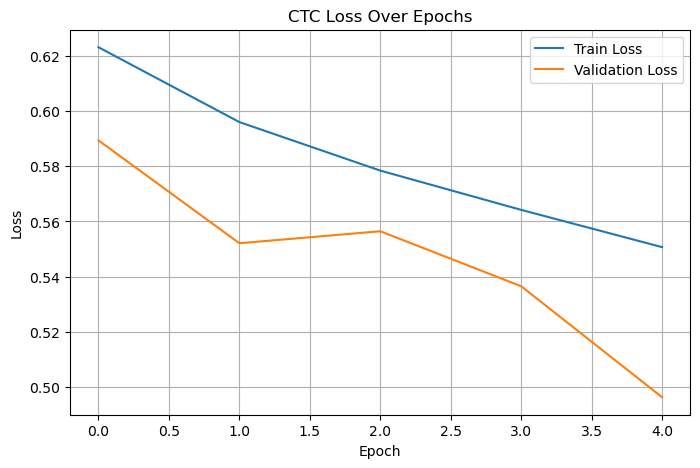

In [36]:
model = SimpleCNN(num_classes=1)
bm = BoxMachine(model, LEARNING_RATE, DEVICE)
bm.train(train_loader, test_loader, epochs=5)
bm.draw_model_dynamic()

In [37]:
bm.save_checkpoint('../checkpoints/checkpoint_lab1_model2.pt')
best_model = SimpleCNN(num_classes=1).to(DEVICE)
bm_checkpoint = torch.load('../checkpoints/checkpoint_lab1_model2.pt', weights_only=True)
best_model.load_state_dict(bm_checkpoint["model_state_dict"])
evaluate(best_model, test_loader)

Metric: 0.6856; Epoch: 1
Accurasy: 0.730
Precision: 0.683
Recall: 0.676
F1: 0.673


___

## TIMM Mobile NetV4

Epoch 1/5 - Train Loss: 1.3063 - Val Loss: 0.5309 - Val metric: 0.6729
Epoch 2/5 - Train Loss: 0.6330 - Val Loss: 0.4026 - Val metric: 0.6843
Epoch 3/5 - Train Loss: 0.4389 - Val Loss: 0.2875 - Val metric: 0.6851
Epoch 4/5 - Train Loss: 0.2948 - Val Loss: 0.2229 - Val metric: 0.6874
Epoch 5/5 - Train Loss: 0.2137 - Val Loss: 0.2008 - Val metric: 0.6853


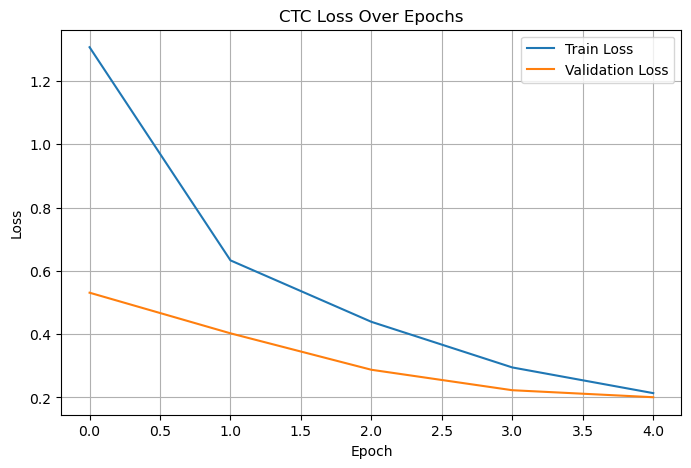

In [39]:
model = timm.create_model(model_name="mobilenetv4_conv_small.e2400_r224_in1k",
                  pretrained=True, num_classes=1)
bm = BoxMachine(model, LEARNING_RATE, DEVICE)
bm.train(train_loader, test_loader, epochs=5)
bm.draw_model_dynamic()

In [40]:
bm.save_checkpoint('../checkpoints/checkpoint_lab1_model3.pt')
#best_model = SimpleCNN(num_classes=1).to(DEVICE)
bm_checkpoint = torch.load('../checkpoints/checkpoint_lab1_model3.pt', weights_only=True)
model.load_state_dict(bm_checkpoint["model_state_dict"])
evaluate(model, test_loader)

Metric: 0.6874; Epoch: 4
Accurasy: 0.942
Precision: 0.703
Recall: 0.672
F1: 0.685


___

## TIMM Mobile Vit

Epoch 1/5 - Train Loss: 0.2824 - Val Loss: 0.0773 - Val metric: 0.7054
Epoch 2/5 - Train Loss: 0.0582 - Val Loss: 0.0325 - Val metric: 0.7074
Epoch 3/5 - Train Loss: 0.0529 - Val Loss: 0.0243 - Val metric: 0.7078
Epoch 4/5 - Train Loss: 0.0199 - Val Loss: 0.0166 - Val metric: 0.7080
Epoch 5/5 - Train Loss: 0.0254 - Val Loss: 0.0168 - Val metric: 0.7076


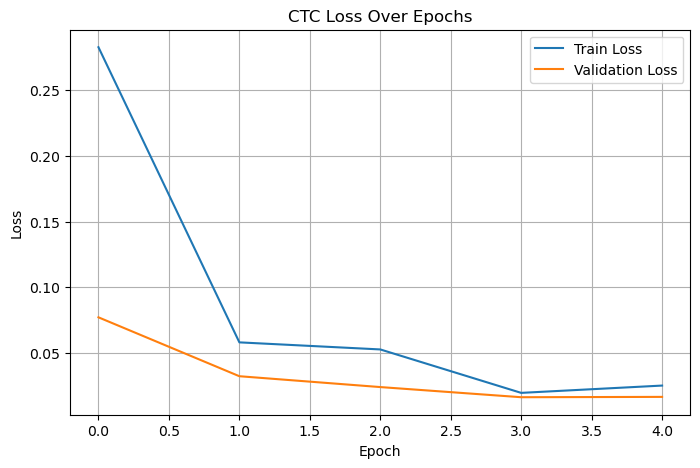

In [13]:
model = timm.create_model(model_name="mobilevit_s.cvnets_in1k",
                  pretrained=True, num_classes=1)
bm = BoxMachine(model, LEARNING_RATE, DEVICE)
bm.train(train_loader, test_loader, epochs=5)
bm.draw_model_dynamic()

In [14]:
bm.save_checkpoint('../checkpoints/checkpoint_lab1_model4.pt')
bm_checkpoint = torch.load('../checkpoints/checkpoint_lab1_model4.pt', weights_only=True)
model.load_state_dict(bm_checkpoint["model_state_dict"])
evaluate(model, test_loader)

Metric: 0.7080; Epoch: 4
Accurasy: 0.996
Precision: 0.708
Recall: 0.707
F1: 0.708


___

## Some Shirt

In [64]:
class CRNN(nn.Module):
    """
    CRNN

    Args:
        in_channels (int):
        out_channels (int):
    """
    def __init__(self, in_channels, out_channels):
        super(CRNN, self).__init__()
        self.in_channels = in_channels
        hidden_size = 256
        self.cnn_struct = ((64, ), (128, ), (256, 256), (512, 512), (512, ))
        self.cnn_paras = ((3, 1, 1), (3, 1, 1),
                          (3, 1, 1), (3, 1, 1), (2, 1, 0))
        self.pool_struct = ((2, 2), (2, 2), (2, 1), (2, 1), None)
        self.batchnorm = (False, False, False, True, False)
        self.cnn = self._get_cnn_layers()
        self.rnn1 = nn.LSTM(self.cnn_struct[-1][-1], hidden_size, bidirectional=True)
        self.rnn2 = nn.LSTM(hidden_size*2, hidden_size, bidirectional=True)
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(hidden_size*2*24, out_channels))
        self._initialize_weights()

    def forward(self, x):           # input: height=32, width>=100
        x = self.cnn(x)             # batch, channel=512, height=1, width>=24
        x = x.squeeze(2)            # batch, channel=512, width>=24
        x = x.permute(2, 0, 1)      # width>=24, batch, channel=512
        x = self.rnn1(x)[0]         # length=width>=24, batch, channel=256*2
        x = self.rnn2(x)[0]         # length=width>=24, batch, channel=256*2
        x = x.permute(1, 0, 2)
        x = self.fc(x)              #
        return x

    def _get_cnn_layers(self):
        cnn_layers = []
        in_channels = self.in_channels
        for i in range(len(self.cnn_struct)):
            for out_channels in self.cnn_struct[i]:
                cnn_layers.append(
                    nn.Conv2d(in_channels, out_channels, *(self.cnn_paras[i])))
                if self.batchnorm[i]:
                    cnn_layers.append(nn.BatchNorm2d(out_channels))
                cnn_layers.append(nn.ReLU(inplace=True))
                in_channels = out_channels
            if (self.pool_struct[i]):
                cnn_layers.append(nn.MaxPool2d(self.pool_struct[i]))
        return nn.Sequential(nn.Sequential(*cnn_layers), nn.AdaptiveAvgPool2d((1, 24)))

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, np.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

Epoch 1/5 - Train Loss: 0.6186 - Val Loss: 0.5787 - Val metric: 0.6844
Epoch 2/5 - Train Loss: 0.5887 - Val Loss: 0.5619 - Val metric: 0.6746
Epoch 3/5 - Train Loss: 0.5761 - Val Loss: 0.5570 - Val metric: 0.6706
Epoch 4/5 - Train Loss: 0.5764 - Val Loss: 0.5515 - Val metric: 0.6778
Epoch 5/5 - Train Loss: 0.5563 - Val Loss: 0.5928 - Val metric: 0.6831


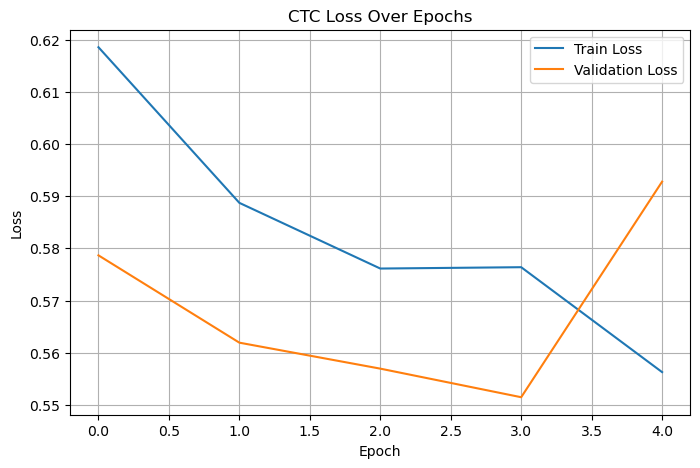

In [66]:
model = CRNN(3, 1).to(DEVICE)
bm = BoxMachine(model, LEARNING_RATE, DEVICE)
bm.train(train_loader, test_loader, epochs=5)
bm.draw_model_dynamic()

In [67]:
bm.save_checkpoint('../checkpoints/checkpoint_lab1_model5.pt')
bm_checkpoint = torch.load('../checkpoints/checkpoint_lab1_model5.pt', weights_only=True)
model.load_state_dict(bm_checkpoint["model_state_dict"])
evaluate(model, test_loader)

Metric: 0.6844; Epoch: 1
Accurasy: 0.689
Precision: 0.680
Recall: 0.702
F1: 0.683


____
____
____

In [68]:
pd.DataFrame({'Accuracy':[0.77, 0.73, 0.94, 0.996, 0.69], 
              'Precision':[0.69, 0.68, 0.70, 0.71, 0.68], 
              'Recall':[0.57, 0.67, 0.67, 0.71, 0.71], 
              'F1':[0.61, 0.67, 0.69, 0.71, 0.68]}, index=['ResNET', 'SimpRNN', 'MobileNetV4', 'MobileVIT', 'Some Shirt'])

,Accuracy,Precision,Recall,F1
ResNET,0.770,0.69,0.57,0.61
SimpRNN,0.730,0.68,0.67,0.67
MobileNetV4,0.940,0.70,0.67,0.69
MobileVIT,0.996,0.71,0.71,0.71
Some Shirt,0.690,0.68,0.71,0.68


___